In [26]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [27]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['method'], group_keys=False).head(k)
    topk_d = topk_df[['method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [28]:
# For gaussian errors, we simply combine previous results with LAD results
data_gaussian = pd.read_csv('results/200_gaussian_6.csv')

# For slash errors
data_slash = pd.read_csv('results/200_slash_6.csv')

<Axes: xlabel='method', ylabel='rmse'>

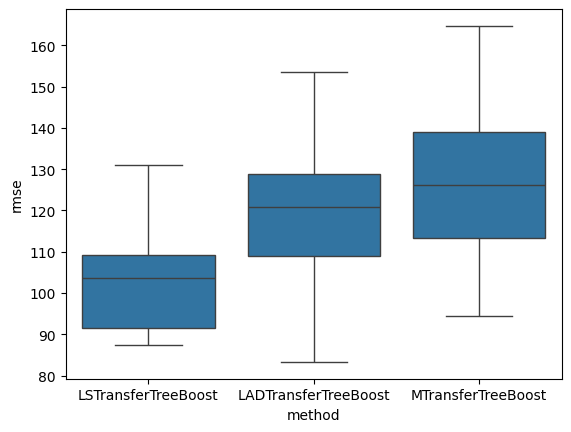

In [29]:

# Here we find the optimal settings
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

sns.boxplot(data = df, x = 'method', y = 'rmse')




<Axes: xlabel='method', ylabel='rmse'>

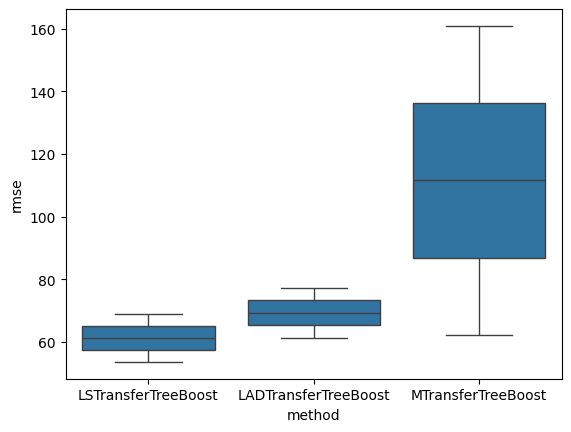

In [30]:
# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=20
)

#create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

sns.boxplot(data = df, x = 'method', y = 'rmse')

